In [ ]:
import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from krono import const
import dill as pickle
from scipy.integrate import trapezoid
from importlib import reload

# to make this plot we load the unabridged output: pickled dictionaries containing many geoid.geoid objects, written by uranus_shape.ipynb and neptune_shape.ipynb
with open('models/geoid_objects/uranus.pkl', 'rb') as fr:
    uranus_models = pickle.load(fr)
with open('models/geoid_objects/neptune.pkl', 'rb') as fr:
    neptune_models = pickle.load(fr)


neptune voyager: std=31.98131274028022, c34=31.490864932527543
neptune hband14: std=106.80139471053143, c34=103.05755432038546
neptune kband14: std=171.25101048660932, c34=151.1458851457906


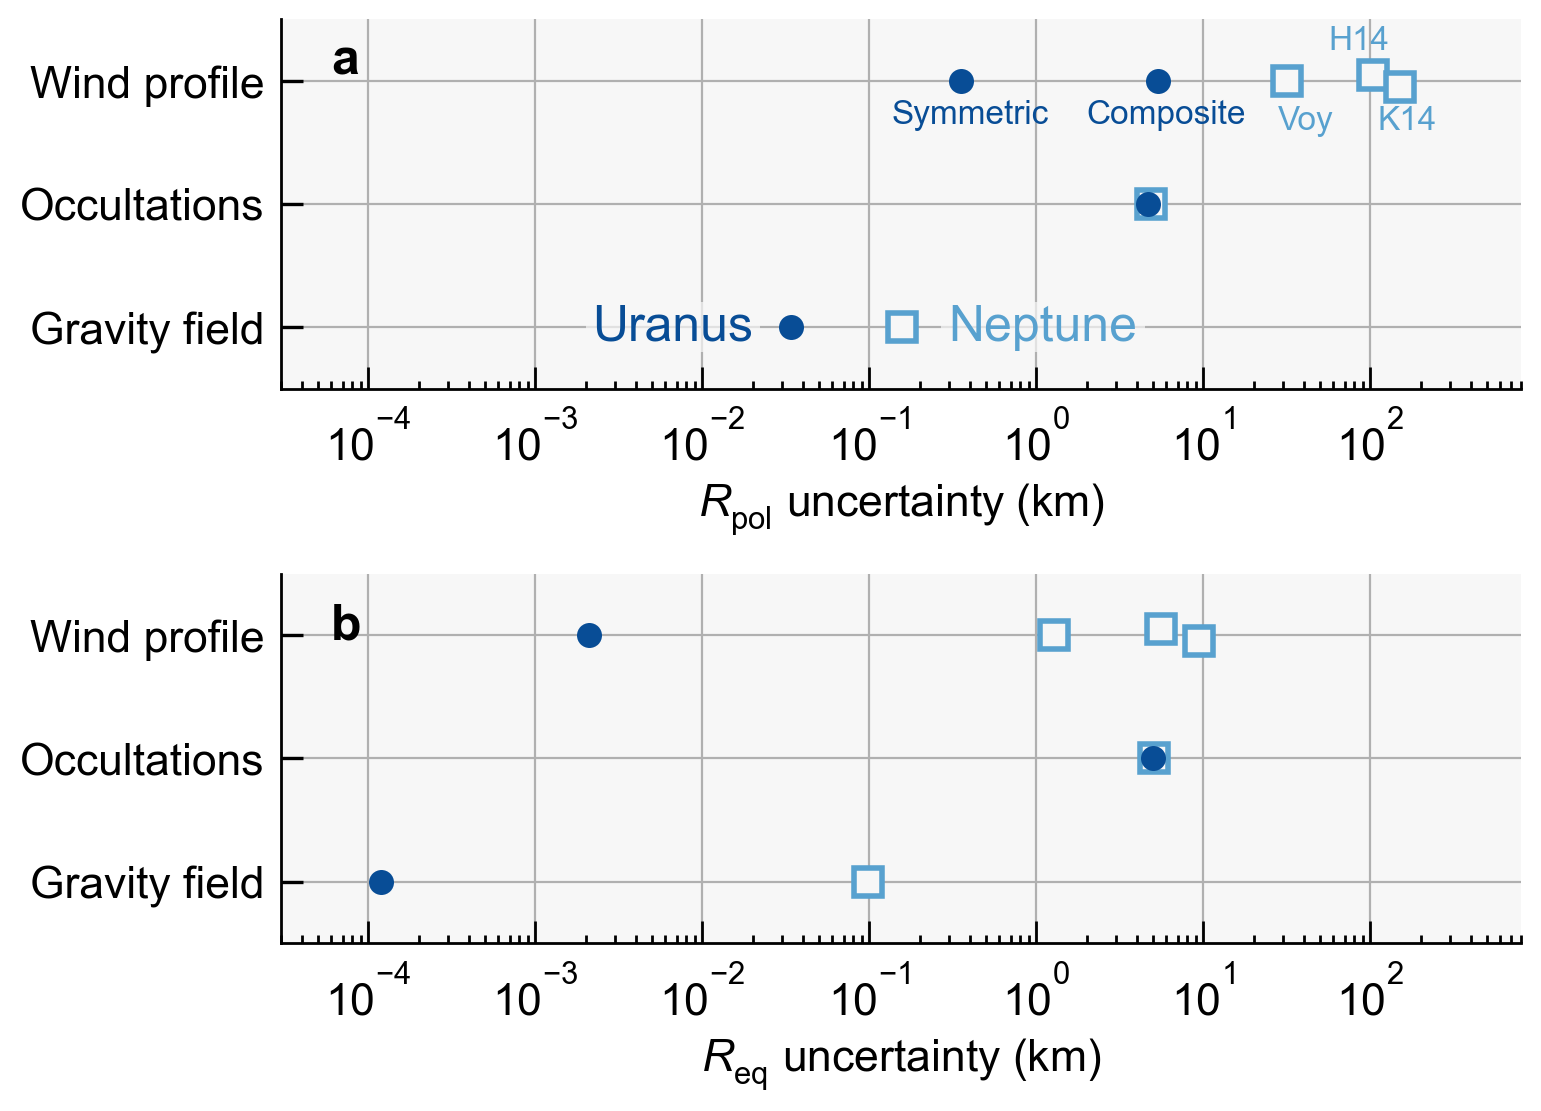

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'hspace':0.5})
# labels = np.array(['Vary winds', r'Vary $R_{\rm occ}$', r'Vary $J_{2n}$'])
labels = np.array(['Wind profile', 'Occultations', 'Gravity field'])
ax[0].set_yticks([0, -1, -2], labels)
ax[1].set_yticks([0, -1, -2], labels)
grey = '#f7f7f7'

# uranus
color = plt.get_cmap('Blues')(0.888)
# color = plt.get_cmap('Purples')(0.777)
spec = {
    'marker':'o',
    'zorder':3,
    'mfc':color,
    'mew':1,
    'mec':'none',
    'ms':9,
}

# max r_pol range given by north versus south polar radius from composite wind fit
rng_rp_vary_winds = uranus_models['vary_wind']['composite'].r[0] - uranus_models['vary_wind']['composite'].r[-1]
# spread associated with random errors on symmetric wind fit
std_rp_vary_winds = np.std(np.array([g.r[0] for i, g in uranus_models['vary_wind']['symmetric'].items()]))
std_re_vary_winds = np.std(np.array([g.r[len(g.mu) // 2] for i, g in uranus_models['vary_wind']['symmetric'].items()]))
# spread from sigma_Rocc~5 km; probably also just 5km
std_rp_vary_ro = np.std(np.array([g.r[0] for i, g in uranus_models['vary_ro']['symmetric'].items()])) # same for composite
std_re_vary_ro = np.std(np.array([g.r[len(g.mu) // 2] for i, g in uranus_models['vary_ro']['symmetric'].items()])) # same for composite
# spread from jn uncertainties
std_rp_vary_jn = np.std(np.array([g.r[0] for i, g in uranus_models['vary_jn']['symmetric'].items()])) # same for composite
std_re_vary_jn = np.std(np.array([g.r[len(g.mu) // 2] for i, g in uranus_models['vary_jn']['symmetric'].items()])) # same for composite

special_spec = spec.copy()
# special_spec.update({'mec':color, 'mfc':'none'})
special_spec.update({'ms':5,})
ax[0].plot(1e-5 * rng_rp_vary_winds, 0, **spec)
ax[0].plot(1e-5 * std_rp_vary_winds, 0, **spec)
ax[0].plot(1e-5 * std_rp_vary_ro, -1, **spec)
ax[0].plot(1e-5 * std_rp_vary_jn, -2, **spec)
ax[1].plot(1e-5 * std_re_vary_winds, 0, **spec)
ax[1].plot(1e-5 * std_re_vary_ro, -1, **spec)
ax[1].plot(1e-5 * std_re_vary_jn, -2, **spec)
ax[0].text(1e-2*2, -2, 'Uranus', fontsize=18, ha='right', va='center', color=color)
ax[0].text(4e-1, -0.15, 'Symmetric', fontsize=12, rotation=0, ha='center', va='top', color=color)
ax[0].text(6e0 , -0.15, 'Composite', fontsize=12, rotation=0, ha='center', va='top', color=color)

# write the plotted points to plaintext
with open('models/uncertainties_summary.txt', 'w') as fw:
    fw.write('uncertainties in uranus (u_) and neptune (n_) polar and equatorial radii, in km, considering uncertainties in the input wind profiles, \n')
    fw.write('occultation radii, or zonal gravity moments jn. for a complete description see Mankovich et al. 2026 (PSJ) Section 4.\n')
    fw.write(f"{'u_rp_compositewind_range_polar_asymmetry':40} {1e-5 * rng_rp_vary_winds:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_winds':40} {1e-5 * std_rp_vary_winds:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_rocc':40} {1e-5 * std_rp_vary_ro:.1e}\n")
    fw.write(f"{'u_rp_symmetricwind_stddev_vary_jn':40} {1e-5 * std_rp_vary_jn:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_winds':40} {1e-5 * std_re_vary_winds:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_ro':40} {1e-5 * std_re_vary_ro:.1e}\n")
    fw.write(f"{'u_re_symmetricwind_stddev_vary_jn':40} {1e-5 * std_re_vary_jn:.1e}\n")

# Neptune
color = plt.get_cmap('Blues')(0.555)
# color = plt.get_cmap('Greens')(0.666)
spec = {
    'marker':'s',
    'mfc':grey,
    'mec':color,
    'mew':2,
    'zorder':2,
    'ms':10,
}

# spread associated with random errors on wind fit
rp_voy = np.array([g.r[0] for i, g in neptune_models['vary_wind']['voyager'].items()])
rp_h14 = np.array([g.r[0] for i, g in neptune_models['vary_wind']['h-band 2014'].items()])
rp_k14 = np.array([g.r[0] for i, g in neptune_models['vary_wind']['k-band 2014'].items()])
c34_rp_voy = 0.5 * (np.quantile(rp_voy, 0.5 + 0.34) - np.quantile(rp_voy, 0.5 - 0.34))
c34_rp_h14 = 0.5 * (np.quantile(rp_h14, 0.5 + 0.34) - np.quantile(rp_h14, 0.5 - 0.34))
c34_rp_k14 = 0.5 * (np.quantile(rp_k14, 0.5 + 0.34) - np.quantile(rp_k14, 0.5 - 0.34))
print(f'neptune voyager: std={1e-5*np.std(rp_voy)}, c34={1e-5*c34_rp_voy}')
print(f'neptune hband14: std={1e-5*np.std(rp_h14)}, c34={1e-5*c34_rp_h14}')
print(f'neptune kband14: std={1e-5*np.std(rp_k14)}, c34={1e-5*c34_rp_k14}')
re_voy = np.array([g.r[len(g.mu) // 2] for i, g in neptune_models['vary_wind']['voyager'].items()])
re_h14 = np.array([g.r[len(g.mu) // 2] for i, g in neptune_models['vary_wind']['h-band 2014'].items()])
re_k14 = np.array([g.r[len(g.mu) // 2] for i, g in neptune_models['vary_wind']['k-band 2014'].items()])
c34_re_voy = np.quantile(re_voy, 0.5 + 0.34) - np.quantile(re_voy, 0.5)
c34_re_h14 = np.quantile(re_h14, 0.5 + 0.34) - np.quantile(re_h14, 0.5)
c34_re_k14 = np.quantile(re_k14, 0.5 + 0.34) - np.quantile(re_k14, 0.5)
# spread from sigma_Rocc=5 km
std_rp_vary_ro = np.std(np.array([g.r[0] for i, g in neptune_models['vary_ro']['voyager'].items()]))
std_re_vary_ro = np.std(np.array([g.r[len(g.mu) // 2] for i, g in neptune_models['vary_ro']['voyager'].items()]))
# spread from sigma_jn
std_rp_vary_jn = np.std(np.array([g.r[0] for i, g in neptune_models['vary_jn']['voyager'].items()]))
std_re_vary_jn = np.std(np.array([g.r[len(g.mu) // 2] for i, g in neptune_models['vary_jn']['voyager'].items()]))

ax[0].plot(1e-5 * c34_rp_voy,  0,    **spec)
ax[0].plot(1e-5 * c34_rp_h14,  0.05, **spec)
ax[0].plot(1e-5 * c34_rp_k14, -0.05, **spec)
ax[1].plot(1e-5 * c34_re_voy,  0,    **spec)
ax[1].plot(1e-5 * c34_re_h14,  0.05, **spec)
ax[1].plot(1e-5 * c34_re_k14, -0.05, **spec)
ax[0].plot(1e-5 * std_rp_vary_ro, -1, **spec)
ax[1].plot(1e-5 * std_re_vary_ro, -1, **spec)
ax[0].plot(1e-5 * std_rp_vary_jn, -2, **spec)
ax[1].plot(1e-5 * std_re_vary_jn, -2, **spec)

ax[0].text(4, -2, 'Neptune', fontsize=18, ha='right', va='center', color=color)
ax[0].text(6e1, -0.2, 'Voy', fontsize=12, rotation=0, ha='right', va='top', color=color)
ax[0].text(1.3e2, 0.2, 'H14', fontsize=12, rotation=0, ha='right', va='bottom', color=color)
ax[0].text(2.5e2, -0.20, 'K14', fontsize=12, rotation=0, ha='right', va='top', color=color)

# write the plotted points to plaintext
with open('models/uncertainties_summary.txt', 'a') as fw:
    fw.write(f"{'n_rp_half_c68_voyagerwind':40} {1e-5 * c34_rp_voy:.1e}\n")
    fw.write(f"{'n_rp_half_c68_hband2014wind':40} {1e-5 * c34_rp_h14:.1e}\n")
    fw.write(f"{'n_rp_half_c68_kband2014wind':40} {1e-5 * c34_rp_k14:.1e}\n")
    fw.write(f"{'n_rp_stddev_voyagerwind_vary_ro':40} {1e-5 * std_rp_vary_ro:.1e}\n")
    fw.write(f"{'n_rp_stddev_voyagerwind_vary_jn':40} {1e-5 * std_rp_vary_jn:.1e}\n")
    fw.write(f"{'n_re_half_c68_voyagerwind':40} {1e-5 * c34_re_voy:.1e}\n")
    fw.write(f"{'n_re_half_c68_hband2014wind':40} {1e-5 * c34_re_h14:.1e}\n")
    fw.write(f"{'n_re_half_c68_kband2014wind':40} {1e-5 * c34_re_k14:.1e}\n")
    fw.write(f"{'n_re_stddev_voyagerwind_vary_ro':40} {1e-5 * std_re_vary_ro:.1e}\n")
    fw.write(f"{'n_re_stddev_voyagerwind_vary_jn':40} {1e-5 * std_re_vary_jn:.1e}\n")

from matplotlib.patches import Rectangle
x1, x2 = 2e-3, 2.2e-2
y1, y2 = -2.2, -1.8
ax[0].add_artist(Rectangle((x1, y1), x2-x1, y2-y1, facecolor=grey, edgecolor='none', lw=1, zorder=2, alpha=0.7))
x1, x2 = 2.7e-1, 4.5e-0
ax[0].add_artist(Rectangle((x1, y1), x2-x1, y2-y1, facecolor=grey, edgecolor='none', lw=1, zorder=2, alpha=0.7))

# ax.tick_params(left=False, labelleft=False, right=False, which='both')
[z.set_yticks([], minor=True) for z in ax]
[z.tick_params(right=False, top=False, which='both') for z in ax]
ax[0].set_xlabel(r'$R_{\rm pol}$ uncertainty (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ uncertainty (km)')

# ax[0].set_xlim(1e-2, 3e2)
[z.set_xlim(3e-5, 8e2) for z in ax]
[z.set_ylim(-2.5, 0.5) for z in ax]

[z.spines[['right', 'top']].set_visible(False) for z in ax.flatten()]
[z.grid() for z in ax]

for iax, c in enumerate('ab'):
    ax[iax].text(0.04, 0.95 if iax == 0 else 0.92, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)  

[z.set_facecolor(grey) for z in ax]
# [z.spines[['left']].set_visible(False) for z in ax.flatten()]
[z.set_xscale('log') for z in ax]

plt.savefig('figures/un_shape_uncertainties.pdf')
